# Libraries

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })

# Read dataset

### Excel

In [2]:
filename_excel = '/home/wmpjrufg/Documents/ic_andre_rimes/tsne/Dados para machine learning.xlsx'

In [3]:
df = pd.read_excel(filename_excel, sheet_name="Dataset experimental")
colunas_para_manter = df.columns[~df.columns.str.contains('Normalizado', case=False, na=False)]
df_filtrado = df[colunas_para_manter]
df_filtrado

,Autor,Diâmetro da armadura f (mm),Número de barras em uma camada,Espaçamento entre as barras (mm),Resistência à compressão do concreto fcm (MPa),Resistência à tração do concreto fctm (MPa),Cobrimento c (mm),Distância ao centro de gravidade da armadura d' (mm),Largura do elemento - b (mm),Altura do elemento - h (mm),Altura útil - d (mm),Área de armadura tracionada (mm2),Taxa de armadura,Tensão na armadura ss (MPa),Resistência ao escoamento do aço (MPa),Momento fletor (kNm),wexp (mm)
0,Viga S200-1.76-20 - Sokolov et al (2021),20.0,2,126.0,50.90,4.120341,25.0,39.0,216.0,201.0,162.0,628.0,0.014465,231.811005,500,20.800,0.16
1,NaN,20.0,2,126.0,50.90,4.120341,25.0,39.0,216.0,201.0,162.0,628.0,0.014465,304.251944,500,27.300,0.23
2,NaN,20.0,2,126.0,50.90,4.120341,25.0,39.0,216.0,201.0,162.0,628.0,0.014465,314.282228,500,28.200,0.24
3,NaN,20.0,2,126.0,50.90,4.120341,25.0,39.0,216.0,201.0,162.0,628.0,0.014465,363.319171,500,32.600,0.27
4,NaN,20.0,2,126.0,50.90,4.120341,25.0,39.0,216.0,201.0,162.0,628.0,0.014465,459.164106,500,41.200,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,NaN,28.7,2,50.6,25.17,2.576579,38.0,52.3,152.4,584.2,531.9,1290.0,0.014489,248.170924,276,149.268,0.19
337,NaN,28.7,2,50.6,25.17,2.576579,38.0,52.3,152.4,584.2,531.9,1290.0,0.014489,275.800000,276,168.882,0.22
338,Viga 23-6-11-2 - Clark (1956),35.8,2,36.4,24.75,2.547836,38.0,55.9,152.4,584.2,528.3,2012.0,0.022599,184.086481,276,167.034,0.17
339,Viga 23-6-11-3 - Clark (1956),35.8,2,36.4,27.85,2.756373,38.0,55.9,152.4,584.2,528.3,2012.0,0.022599,143.792877,276,130.788,0.19


In [4]:
df_filtrado.to_excel('crack_dataset.xlsx', index=False)

In [5]:
df_filtrado.columns

Index(['Autor', 'Diâmetro da armadura f (mm)',
       'Número de barras em uma camada', 'Espaçamento entre as barras (mm)',
       'Resistência à compressão do concreto fcm (MPa)',
       'Resistência à tração do concreto fctm (MPa)', 'Cobrimento c (mm)',
       'Distância ao centro de gravidade da armadura d' (mm)',
       'Largura do elemento - b (mm)', 'Altura do elemento - h (mm)',
       'Altura útil - d (mm)', 'Área de armadura tracionada (mm2)',
       'Taxa de armadura', 'Tensão na armadura  ss (MPa)',
       'Resistência ao escoamento do aço (MPa)', 'Momento fletor (kNm)',
       'wexp (mm)'],
      dtype='object')

In [6]:
x = df_filtrado[['Diâmetro da armadura f (mm)',
       'Número de barras em uma camada', 'Espaçamento entre as barras (mm)',
       'Resistência à compressão do concreto fcm (MPa)',
       'Resistência à tração do concreto fctm (MPa)', 'Cobrimento c (mm)',
       "Distância ao centro de gravidade da armadura d' (mm)",
       'Largura do elemento - b (mm)', 'Altura do elemento - h (mm)',
       'Área de armadura tracionada (mm2)',
       'Taxa de armadura', 'Tensão na armadura  ss (MPa)',
       'Resistência ao escoamento do aço (MPa)', 'Momento fletor (kNm)']]
x

,Diâmetro da armadura f (mm),Número de barras em uma camada,Espaçamento entre as barras (mm),Resistência à compressão do concreto fcm (MPa),Resistência à tração do concreto fctm (MPa),Cobrimento c (mm),Distância ao centro de gravidade da armadura d' (mm),Largura do elemento - b (mm),Altura do elemento - h (mm),Área de armadura tracionada (mm2),Taxa de armadura,Tensão na armadura ss (MPa),Resistência ao escoamento do aço (MPa),Momento fletor (kNm)
0,20.0,2,126.0,50.90,4.120341,25.0,39.0,216.0,201.0,628.0,0.014465,231.811005,500,20.800
1,20.0,2,126.0,50.90,4.120341,25.0,39.0,216.0,201.0,628.0,0.014465,304.251944,500,27.300
2,20.0,2,126.0,50.90,4.120341,25.0,39.0,216.0,201.0,628.0,0.014465,314.282228,500,28.200
3,20.0,2,126.0,50.90,4.120341,25.0,39.0,216.0,201.0,628.0,0.014465,363.319171,500,32.600
4,20.0,2,126.0,50.90,4.120341,25.0,39.0,216.0,201.0,628.0,0.014465,459.164106,500,41.200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,28.7,2,50.6,25.17,2.576579,38.0,52.3,152.4,584.2,1290.0,0.014489,248.170924,276,149.268
337,28.7,2,50.6,25.17,2.576579,38.0,52.3,152.4,584.2,1290.0,0.014489,275.800000,276,168.882
338,35.8,2,36.4,24.75,2.547836,38.0,55.9,152.4,584.2,2012.0,0.022599,184.086481,276,167.034
339,35.8,2,36.4,27.85,2.756373,38.0,55.9,152.4,584.2,2012.0,0.022599,143.792877,276,130.788


In [7]:
y = df_filtrado[['wexp (mm)']]
y

,wexp (mm)
0,0.16
1,0.23
2,0.24
3,0.27
4,0.35
...,...
336,0.19
337,0.22
338,0.17
339,0.19


### Divided in three groups

In [8]:
y = y.squeeze()
y_class = pd.qcut(y, q=3, labels=["low", "medium", "high"])
df_labels = pd.DataFrame({"w": y, "class_w": y_class})
df_labels.head()

,w,class_w
0,0.16,low
1,0.23,medium
2,0.24,medium
3,0.27,medium
4,0.35,high


### Count the groups

In [9]:
df_labels["class_w"].value_counts()

class_w
low       139
high      107
medium     95
Name: count, dtype: int64

### Crack width classification

In [10]:
low = df_labels[df_labels["class_w"] == "low"]
medium = df_labels[df_labels["class_w"] == "medium"]
high = df_labels[df_labels["class_w"] == "high"]

In [11]:
low.describe()
text_low = rf"$w_{{min}}$: {low['w'].min():.2f}, $w_{{max}}$: {low['w'].max():.2f}"
text_low

'$w_{min}$: 0.14, $w_{max}$: 0.20'

In [12]:
medium.describe()
text_medium = rf"$w_{{min}}$: {medium['w'].min():.2f}, $w_{{max}}$: {medium['w'].max():.2f}"
text_medium

'$w_{min}$: 0.21, $w_{max}$: 0.27'

In [13]:
high.describe()
text_high = rf"$w_{{min}}$: {high['w'].min():.2f}, $w_{{max}}$: {high['w'].max():.2f}"
text_high

'$w_{min}$: 0.28, $w_{max}$: 0.79'

# Run TSNE ML

In [14]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
tsne = TSNE(
                n_components=2,
                perplexity=30,
                learning_rate="auto",
                init="pca",
                random_state=42
            )

x_tsne = tsne.fit_transform(x_scaled)
tsne_df = pd.DataFrame(
                            x_tsne,
                            columns=["tSNE1", "tSNE2"],
                            index=x.index
                       )

tsne_df["class_crack"] = y_class.values
tsne_df

,tSNE1,tSNE2,class_crack
0,-3.402728,15.789738,low
1,-3.380011,16.005373,medium
2,-3.377109,16.044851,medium
3,-3.361441,16.295446,medium
4,-3.341638,16.858017,high
...,...,...,...
336,14.269279,-6.976906,low
337,14.139598,-7.207083,medium
338,15.632448,-7.197498,low
339,15.787850,-7.076479,low


In [15]:
tsne_df.loc[tsne_df["class_crack"] == "low", "class_w"] = text_low
tsne_df.loc[tsne_df["class_crack"] == "medium", "class_w"] = text_medium
tsne_df.loc[tsne_df["class_crack"] == "high", "class_w"] = text_high
tsne_df

,tSNE1,tSNE2,class_crack,class_w
0,-3.402728,15.789738,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
1,-3.380011,16.005373,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
2,-3.377109,16.044851,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
3,-3.361441,16.295446,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
4,-3.341638,16.858017,high,"$w_{min}$: 0.28, $w_{max}$: 0.79"
...,...,...,...,...
336,14.269279,-6.976906,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
337,14.139598,-7.207083,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
338,15.632448,-7.197498,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
339,15.787850,-7.076479,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"


In [16]:
tsne_df.to_excel('results_tsne.xlsx', index=False)  

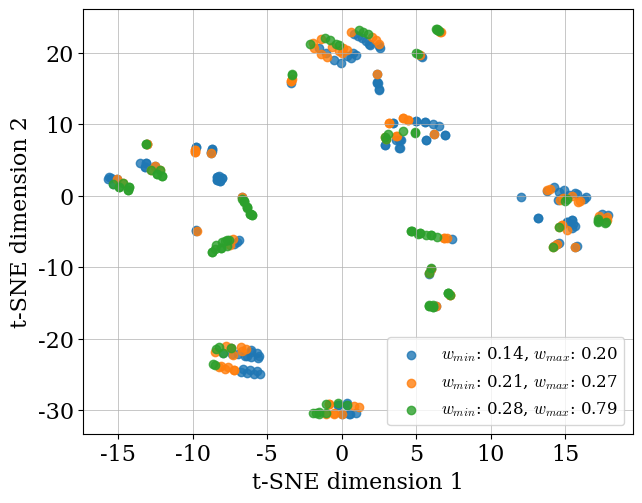

In [19]:
dpi = 600               # Change as you wish
name = 'TSNE_dataset' # Change as you wish

b_cm = 18                       # Change as you wish
h_cm = 14                        # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm


label_x = 't-SNE dimension 1' # Change as you wish
label_y = 't-SNE dimension 2'     # Change as you wish
size_label = 16                 # Change as you wish
color_label = 'black'            # or hexadecimal. Change as you wish
size_axis = 16                  # Change as you wish
color_axis = 'black'              # or hexadecimal. Change as you wish

fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.5)

for classe in tsne_df["class_w"].unique():
    subset = tsne_df[tsne_df["class_w"] == classe]
    ax.scatter(
        subset["tSNE1"],
        subset["tSNE2"],
        label=classe,
        alpha=0.8
    )
    ax.legend(fontsize=12, loc='lower right')
# Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [18]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(x_tsne, y_class)
sil

-0.015528617426753044